In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Dataset/Real estate.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/Real estate.csv'

In [ ]:
# Features -> 2D / DataFrame
# Target -> 1D / Series

In [ ]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [ ]:
features = ['X2 house age','X3 distance to the nearest MRT station',
            'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [ ]:
X = df[features]
Y = df[target]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

### Feature Scaling

In [ ]:
scaler = StandardScaler()

In [ ]:
# (Xi - mean) / sd
# fit_transform -> (fit) Learning and (transform) Implement
# Learning -> calculation of mean and sd
# Implement -> (Xi - mean) / sd
X_train_scale = scaler.fit_transform(X_train)

# Implement -> (Xi - mean) / sd
X_test_scale = scaler.transform(X_test)

### Define Model

In [ ]:
model = LinearRegression()
# fit data into model
# fit feature scaled training record and target training record
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
Y_pred = model.predict(X_test_scale)

### metrics

In [ ]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

In [ ]:
print(f'RMSE: {rmse}')
print(f'RMSE in %: {rmse/414} (Error rate)')
print(f'R2 Score: {r2}')

RMSE: 7.3878917967754605
RMSE in %: 0.017845149267573576 (Error rate)
R2 Score: 0.6746481382828176


### Visualization

In [ ]:
min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())

Text(0, 0.5, 'Predicted House Prices')

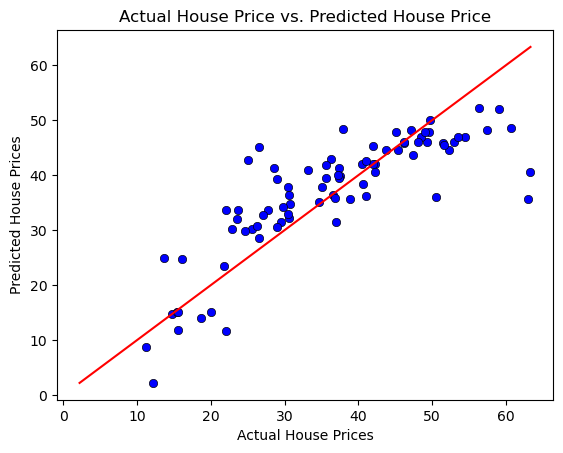

In [ ]:
sns.scatterplot(x=Y_test, y=Y_pred, color='blue', edgecolor='black')
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.title('Actual House Price vs. Predicted House Price')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')

### Predict in new data

In [ ]:
input_data = {
    'X2 house age': [20, 5, 11],
    'X3 distance to the nearest MRT station': [20.4, 85.0, 11.2],
    'X4 number of convenience stores': [3, 0, 4], 
    'X5 latitude': [24.98298, 24.96108, 24.95593], 
    'X6 longitude': [121.51254, 121.53913, 121.54348]
}

In [ ]:
X_new = pd.DataFrame(input_data)

In [ ]:
X_new_scale = scaler.transform(X_new)

In [ ]:
Y_new_pred = model.predict(X_new_scale)

In [ ]:
X_new['predicted house price'] = Y_new_pred

In [ ]:
X_new

NameError: name 'X_new' is not defined